# BreaKHis Preprocessing Pipeline

## Objective

This notebook implements the preprocessing pipeline for histopathology image classification.

The following steps are included:

- train / validation / test split
- dataset-specific normalization
- ImageNet normalization
- data augmentation
- PyTorch dataset and dataloader preparation

In [23]:
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path

base_output_path = Path("/Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs")

figures_path = base_output_path / "figures"
metrics_path = base_output_path / "metrics"
reports_path = base_output_path / "reports"

figures_path.mkdir(parents=True, exist_ok=True)
metrics_path.mkdir(parents=True, exist_ok=True)
reports_path.mkdir(parents=True, exist_ok=True)

print("Figures path:", figures_path)
print("Metrics path:", metrics_path)
print("Reports path:", reports_path)

Figures path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/figures
Metrics path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/metrics
Reports path: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs/reports


In [9]:
train_df = pd.read_csv(reports_path / "train_split.csv")
val_df = pd.read_csv(reports_path / "val_split.csv")
test_df = pd.read_csv(reports_path / "test_split.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 5536
Validation size: 1186
Test size: 1187


## Normalisation Strategy

Two normalisation strategies are prepared in this study.

The first uses BreaKHis-specific RGB mean and standard deviation values calculated during exploratory analysis. This reflects the colour distribution of H&E-stained histopathology images more directly.

The second uses standard ImageNet normalisation values, which align with pretrained ResNet18 weights. Comparing both strategies will allow assessment of whether domain-specific normalisation improves classification performance.

In [11]:
# BreaKHis-specific statistics from Notebook 1
breakhis_mean = [0.79265212, 0.62774458, 0.76449277]
breakhis_std = [0.10090955, 0.13664410, 0.08862125]

# Standard ImageNet statistics
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

print("BreaKHis mean:", breakhis_mean)
print("BreaKHis std:", breakhis_std)
print("ImageNet mean:", imagenet_mean)
print("ImageNet std:", imagenet_std)

BreaKHis mean: [0.79265212, 0.62774458, 0.76449277]
BreaKHis std: [0.10090955, 0.1366441, 0.08862125]
ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std: [0.229, 0.224, 0.225]


In [12]:
image_size = (224, 224)

# training transforms with dataset-specific normalization
train_transform_breakhis = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=breakhis_mean, std=breakhis_std)
])

# validation / test transforms with dataset-specific normalization
eval_transform_breakhis = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=breakhis_mean, std=breakhis_std)
])

# training transforms with ImageNet normalization
train_transform_imagenet = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# validation / test transforms with ImageNet normalization
eval_transform_imagenet = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Transform pipelines created successfully.")

Transform pipelines created successfully.


Only mild data augmentation was applied during training. Horizontal flipping and limited rotation were selected to improve robustness to orientation variation without substantially altering tissue morphology.

## Custom Dataset Class

A custom PyTorch dataset class is defined to load image paths and labels from the pre-generated split dataframes. This allows consistent use of the same split definitions across different normalization strategies and later model experiments.

In [16]:
class BreakHisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "benign": 0,
            "malignant": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        with Image.open(row["filepath"]) as img:
            image = img.convert("RGB")
        label = self.label_map[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
# quick test using dataset-specific normalization
train_dataset_breakhis = BreakHisDataset(train_df, transform=train_transform_breakhis)
val_dataset_breakhis = BreakHisDataset(val_df, transform=eval_transform_breakhis)
test_dataset_breakhis = BreakHisDataset(test_df, transform=eval_transform_breakhis)

print("Train dataset size:", len(train_dataset_breakhis))
print("Validation dataset size:", len(val_dataset_breakhis))
print("Test dataset size:", len(test_dataset_breakhis))

Train dataset size: 5536
Validation dataset size: 1186
Test dataset size: 1187


In [18]:
sample_image, sample_label = train_dataset_breakhis[0]

print("Image tensor shape:", sample_image.shape)
print("Label:", sample_label)

Image tensor shape: torch.Size([3, 224, 224])
Label: 0


## DataLoader Preparation

PyTorch dataloaders are created to batch images efficiently during model training and evaluation. Separate loaders are defined for the training, validation, and test sets. Training batches are shuffled, while validation and test batches are kept in fixed order.

In [19]:
batch_size = 32

train_loader_breakhis = DataLoader(
    train_dataset_breakhis,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader_breakhis = DataLoader(
    val_dataset_breakhis,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader_breakhis = DataLoader(
    test_dataset_breakhis,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader_breakhis))
print("Validation batches:", len(val_loader_breakhis))
print("Test batches:", len(test_loader_breakhis))

Train batches: 173
Validation batches: 38
Test batches: 38


In [20]:
images, labels = next(iter(train_loader_breakhis))

print("Batch image tensor shape:", images.shape)
print("Batch label tensor shape:", labels.shape)
print("Unique labels in batch:", labels.unique())

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch label tensor shape: torch.Size([32])
Unique labels in batch: tensor([0, 1])


In [21]:
def denormalize_image(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

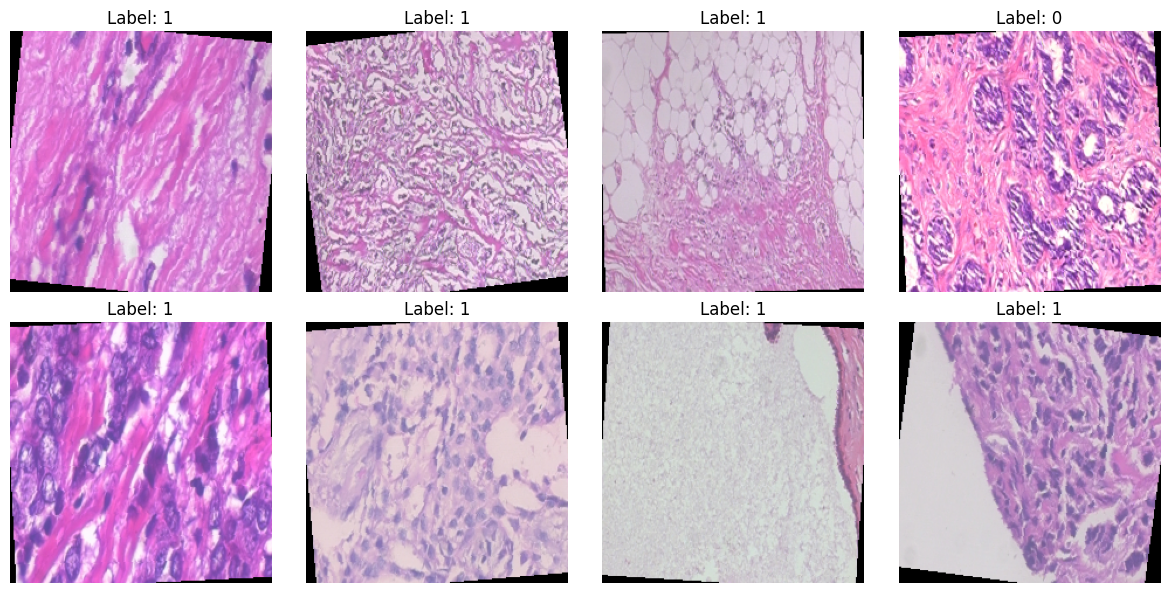

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    img = denormalize_image(images[i], breakhis_mean, breakhis_std)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(figures_path / "figure_04_preprocessed_batch_samples.png", dpi=300)
plt.savefig(figures_path / "figure_04_preprocessed_batch_samples.pdf")
plt.show()